This notebook is the first of two parts time-saving quickstart baseline for you. Submission accuracy is 0.88 in public dataset. I will list model details and tricks for training. If you are experienced in Keras model, reading only the list and skipping the code could be your option.

* Model: Keras EfficientNetB4 with Imagenet weights, (380,380,3) input size, average pooling + 5 class softmax top, without dropout.
* Data generator(augmentation): rotate 45, zoom 0.2, horizontal and vertical flip, height and width shift 0.2, interpolation nearest, validation split 0.2
* Hyperparameters and tricks: epochs 20, batch size 16, learning rate 1e-3, reduce learning rate to 1e-6, early stoping.

In [1]:
import numpy as np
import pandas as pd
import os

Cassava_dir = "../input/cassava-leaf-disease-classification/"

In [2]:
train_df = pd.read_csv(os.path.join(Cassava_dir, "train.csv"))
train_df['label'] = train_df['label'].astype('str')

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
TARGET_SIZE = (380,380)
BATCH_SIZE = 16
STEPS_PER_EPOCH = len(train_df)*0.8 // BATCH_SIZE
VALIDATION_STEPS = len(train_df)*0.2 // BATCH_SIZE
EPOCHS = 20

In [5]:
train_datagen = ImageDataGenerator(validation_split = 0.2,
                                    rotation_range = 45,
                                    zoom_range = 0.2,
                                    horizontal_flip = True,
                                    vertical_flip = True,
                                    fill_mode = 'nearest',
                                    height_shift_range = 0.2,
                                    width_shift_range = 0.2,
                                  )

train_generator = train_datagen.flow_from_dataframe(train_df,
                         directory = os.path.join(Cassava_dir, "train_images"),
                         subset = "training",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = TARGET_SIZE,
                         batch_size = BATCH_SIZE,
                         class_mode = "sparse",
                         seed = 2020,
                         shuffle= True)


validation_datagen = ImageDataGenerator(validation_split = 0.2)

validation_generator = validation_datagen.flow_from_dataframe(train_df,
                         directory = os.path.join(Cassava_dir, "train_images"),
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = TARGET_SIZE,
                         batch_size = BATCH_SIZE,
                         class_mode = "sparse",
                         seed = 2020,
                         shuffle= True)

Found 17118 validated image filenames belonging to 5 classes.
Found 4279 validated image filenames belonging to 5 classes.


In [6]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

basemodel = EfficientNetB4(weights="imagenet", include_top=False,input_shape=TARGET_SIZE+(3,))
headmodel = layers.GlobalAveragePooling2D()(basemodel.output)
headmodel = layers.Dense(5, activation="softmax")(headmodel)
model = keras.Model(inputs=basemodel.input, outputs=headmodel)

71688192/71686520 [==============================] - 1s 0us/step


In [7]:
model_save = ModelCheckpoint('best_weights.h5', 
                             save_best_only = True, 
                             monitor = 'val_loss', 
                             mode = 'min', verbose = 1)
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.3, 
                              patience = 2, min_lr = 1e-6, 
                              mode = 'min', verbose = 1)
early_stop = EarlyStopping(monitor = 'val_loss', 
                           patience = 3, mode = 'min', verbose = 1,
                           restore_best_weights = True)


model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_generator,
    steps_per_epoch = STEPS_PER_EPOCH,
    epochs = EPOCHS,
    validation_data = validation_generator,
    validation_steps = VALIDATION_STEPS,
    callbacks = [model_save, early_stop, reduce_lr],
)

Epoch 1/20
1069/1069 [==============================] - ETA: 0s - loss: 0.6248 - accuracy: 0.7801
Epoch 00001: val_loss improved from inf to 0.53702, saving model to best_weights.h5
1069/1069 [==============================] - 1163s 1s/step - loss: 0.6248 - accuracy: 0.7801 - val_loss: 0.5370 - val_accuracy: 0.8172
Epoch 2/20
1069/1069 [==============================] - ETA: 0s - loss: 0.4912 - accuracy: 0.8335
Epoch 00002: val_loss did not improve from 0.53702
1069/1069 [==============================] - 1079s 1s/step - loss: 0.4912 - accuracy: 0.8335 - val_loss: 0.5477 - val_accuracy: 0.8251
Epoch 3/20
1069/1069 [==============================] - ETA: 0s - loss: 0.4524 - accuracy: 0.8450
Epoch 00003: val_loss improved from 0.53702 to 0.49990, saving model to best_weights.h5
1069/1069 [==============================] - 1100s 1s/step - loss: 0.4524 - accuracy: 0.8450 - val_loss: 0.4999 - val_accuracy: 0.8279
Epoch 4/20
1069/1069 [==============================] - ETA: 0s - loss: 0.4412

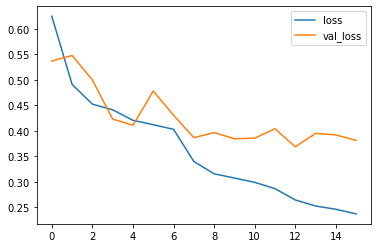

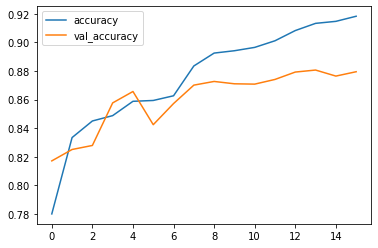

In [8]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()

In [9]:
model.save('weights.h5')

Thanks to the notebooks below for inspiring:
* [https://www.kaggle.com/eceifter/xception-cassava-leaf-disease-classification](https://www.kaggle.com/eceifter/xception-cassava-leaf-disease-classification)
* [https://www.kaggle.com/marto24/cassava-baseline-model](https://www.kaggle.com/marto24/cassava-baseline-model)